# HPC-MEC World Model - Inference Demo

This notebook walks through three inference tasks with a trained model:

1. **One-step prediction** - `model.one_step(X)`: predict each next frame from the
   ground-truth previous latent.
2. **Autoregressive prediction** - `model.autoregressive(X)`: roll the model forward
   from a single initial frame (optionally with periodic feedback).
3. **Transfer** - `model.transfer(x_t, x, period=...)`: apply the latent transitions
   extracted from one sequence onto the content of another, optionally autoregressively.

Tasks 1 and 2 run on **Something-Something-V2 (SSv2)**. The final transfer section
runs on **Omni-Primitive-Transforms**, matching the transfer evaluation in the paper.

> Run this notebook from the repository root (the directory containing `train.py` and `VAR/`).

## 0. Configuration

In [ ]:
import os

# GPU to use (set before torch is imported).
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# --- Paths ---
MODEL_CKPT   = "./checkpoints/model.pth"
SSV2_ROOT    = "./dataset/20bn-something-something-v2/rawframes"
SSV2_LABELS  = "./dataset/labels/test.json"
OMNI_IMG_DIR = "./dataset/omni-primitive-transforms"

# Repository root (this notebook must be able to find ./VAR and ./models).
REPO_ROOT = os.getcwd()
# os.chdir(REPO_ROOT)  # uncomment if the notebook is not launched from the repo root

## 1. Imports

In [2]:
import sys
import os.path as osp

_VAR_DIR = osp.join(REPO_ROOT, "VAR")
sys.path.insert(0, _VAR_DIR)
from VAR.models import build_vae_var
from VAR.utils.data import normalize_01_into_pm1
sys.path.remove(_VAR_DIR)
for _m in list(sys.modules):
    if _m in ("dist", "models", "utils") or _m.startswith(("models.", "utils.")):
        del sys.modules[_m]
del _VAR_DIR

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from einops import rearrange
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

from utils import SomethingSomethingV2Dataset, MultiActionOmniDataset
from models.hierarchical_model import HPC_model, MEC_model, JointHPCMEC, Inverse_World_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 2. Build the VQ-VAE tokenizer and the world model

`build_vae_var` returns `(VQVAE, VAR)`; only the VQ-VAE tokenizer is needed here.
The VQ-VAE checkpoint is downloaded into `VAR/checkpoints/` on first run.

In [3]:
def init_model(model_ckpt):
    MODEL_DEPTH = 16
    assert MODEL_DEPTH in {16, 20, 24, 30}

    # Download the VQ-VAE tokenizer checkpoint if missing.
    hf_home = "https://huggingface.co/FoundationVision/var/resolve/main"
    vae_ckpt = osp.join("VAR", "checkpoints", "vae_ch160v4096z32.pth")
    if not osp.exists(vae_ckpt):
        os.makedirs(osp.dirname(vae_ckpt), exist_ok=True)
        os.system(f"wget -O {vae_ckpt} {hf_home}/{osp.basename(vae_ckpt)}")

    patch_nums = (1, 2, 3, 4, 5, 6, 8, 10, 13, 16)
    # build_vae_var returns (VQVAE, VAR); only the VQVAE tokenizer is needed.
    vae, _var = build_vae_var(
        V=4096, Cvae=32, ch=160, share_quant_resi=4,
        device=device, patch_nums=patch_nums,
        num_classes=1000, depth=MODEL_DEPTH, shared_aln=False,
    )
    vae.load_state_dict(torch.load(vae_ckpt, map_location="cpu"), strict=True)
    vae.eval()
    for p in vae.parameters():
        p.requires_grad_(False)

    hpc_model = HPC_model().to(device)
    mec_model = MEC_model().to(device)
    joint = JointHPCMEC(hpc_model, mec_model).to(device)
    model = Inverse_World_model(joint).to(device)
    model.load_state_dict(torch.load(model_ckpt, map_location="cpu"), strict=True)
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    print("model & tokenizer ready.")
    return model, vae


model, vae = init_model(MODEL_CKPT)
model = model.to(device)
vae = vae.to(device)


[constructor]  ==== flash_if_available=True (0/16), fused_if_available=True (fusing_add_ln=0/16, fusing_mlp=0/16) ==== 
    [VAR config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.0666667 (tensor([0.0000, 0.0044, 0.0089, 0.0133, 0.0178, 0.0222, 0.0267, 0.0311, 0.0356,
        0.0400, 0.0444, 0.0489, 0.0533, 0.0578, 0.0622, 0.0667]))

[init_weights] VAR with init_std=0.0180422
model & tokenizer ready.


## 3. Load SSv2 data

The first two tasks use SSv2 clips. Omni is loaded separately in the final transfer section.

In [4]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    normalize_01_into_pm1,
])

SEQ_LEN = 8
dataset = SomethingSomethingV2Dataset(
    root_dir=SSV2_ROOT,
    annotations_file=SSV2_LABELS,
    transform=transform,
    frames_per_clip=SEQ_LEN,
    sliding_window=SEQ_LEN,
    sample_downsample_rate=1,
)
loader = DataLoader(dataset, batch_size=4, shuffle=False, num_workers=4)

## 4. Encode a batch into latents

Frames are encoded with the VQ-VAE into the multi-scale latent; we keep the largest
scale `fhat` and reshape to `[B, T, C, H, W]`. The SSv2 dataset yields
`[B, num_clips=1, T, C, H, W]`, so `flatten(0, 1)` collapses the clip axis into the batch.

In [5]:
batch = next(iter(loader))

with torch.no_grad():
    # SSv2: the batch is a tensor [B, num_clips=1, T, C, H, W]
    X = batch.to(device)
    X = X.flatten(0, 1)                                  # -> [B, T, C, H, W]

    B, T, _, _, _ = X.size()
    X = vae.quant_conv(vae.encoder(X.flatten(0, 1)))
    X = vae.quantize.f_to_idxBl_or_fhat(X, to_fhat=True, v_patch_nums=vae.quantize.v_patch_nums)
    X = X[-1]                                            # largest scale
    X = rearrange(X, "(b t) c h w -> b t c h w", b=B, t=T)

print("latent X:", tuple(X.shape))

latent X: (4, 8, 32, 16, 16)


## 5. Plotting helpers

`decode` maps latents back to RGB images in `[0, 1]`; `plot_rows` lays out one or more
sequences as rows, with `None` rendered as a blank cell (used to align predictions that
start at frame 1).

In [6]:
@torch.no_grad()
def decode(z):
    """z: [T, C, H, W] latent -> [T, 3, H, W] image in [0, 1]."""
    imgs = vae.decoder(vae.post_quant_conv(z)).clamp_(-1, 1)
    return ((imgs + 1) / 2).clamp(0, 1).cpu()


def plot_rows(rows, row_titles, ncols, figtitle=None):
    """rows: list of lists; each entry is a [3, H, W] tensor or None (blank).

    Row labels are placed to the LEFT of each row (outside the images) and the
    figure title is spaced by constrained_layout, so text never overlaps images.
    """
    nrows = len(rows)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(2 * ncols, 2.2 * nrows),
        squeeze=False,
        constrained_layout=True,
    )
    if figtitle:
        fig.suptitle(figtitle, fontsize=13)
    for r, (row, title) in enumerate(zip(rows, row_titles)):
        for c in range(ncols):
            ax = axes[r][c]
            if c < len(row) and row[c] is not None:
                ax.imshow(row[c].permute(1, 2, 0).numpy())
            else:
                ax.imshow(np.ones((256, 256, 3)))
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            if c == 0:
                ax.set_ylabel(title, rotation=0, ha="right", va="center",
                              fontsize=11, labelpad=12)
    plt.show()

## Task 1 - One-step prediction

`model.one_step(X)` predicts every frame from the **ground-truth** previous latent
(fully teacher-forced). `s_gen` covers frames `1 .. T-1`; we align it under the input
row by placing a blank at frame 0.

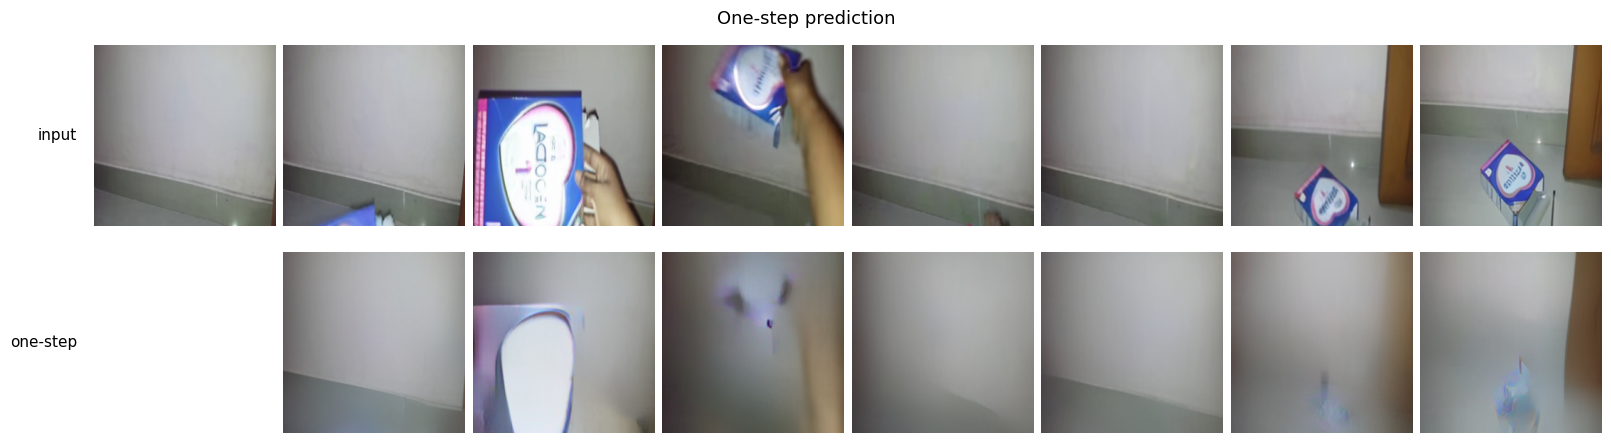

In [7]:
idx = 0  # which sample in the batch to visualize

with torch.no_grad():
    res = model.one_step(X)

gt   = decode(res["x"][idx])        # [T,   3, H, W]
pred = decode(res["s_gen"][idx])    # [T-1, 3, H, W]  (frames 1..T-1)

plot_rows(
    rows=[list(gt), [None] + list(pred)],
    row_titles=["input", "one-step"],
    ncols=T,
    figtitle="One-step prediction",
)

## Task 2 - Autoregressive prediction

`model.autoregressive(X)` rolls the model forward from the first frame, consuming its
**own** previous prediction at every step (no feedback).

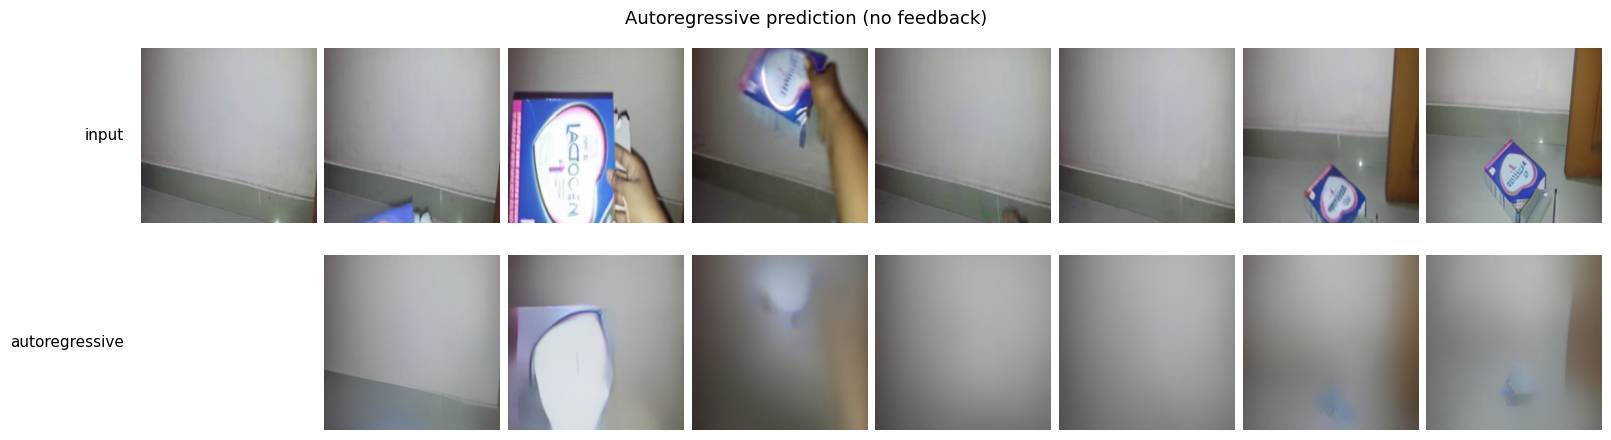

In [8]:
with torch.no_grad():
    res_ar = model.autoregressive(X)

gt   = decode(res_ar["x"][idx])
pred = decode(res_ar["s_gen"][idx])

plot_rows(
    rows=[list(gt), [None] + list(pred)],
    row_titles=["input", "autoregressive"],
    ncols=T,
    figtitle="Autoregressive prediction (no feedback)",
)

## Task 2b - Autoregressive with periodic feedback

`feedback_period=N` re-injects the ground-truth latent every `N` steps, interpolating
between pure autoregression (`N=None`, Task 2) and one-step (`N=1`, Task 1). Smaller `N`
gives more correction and typically less drift.

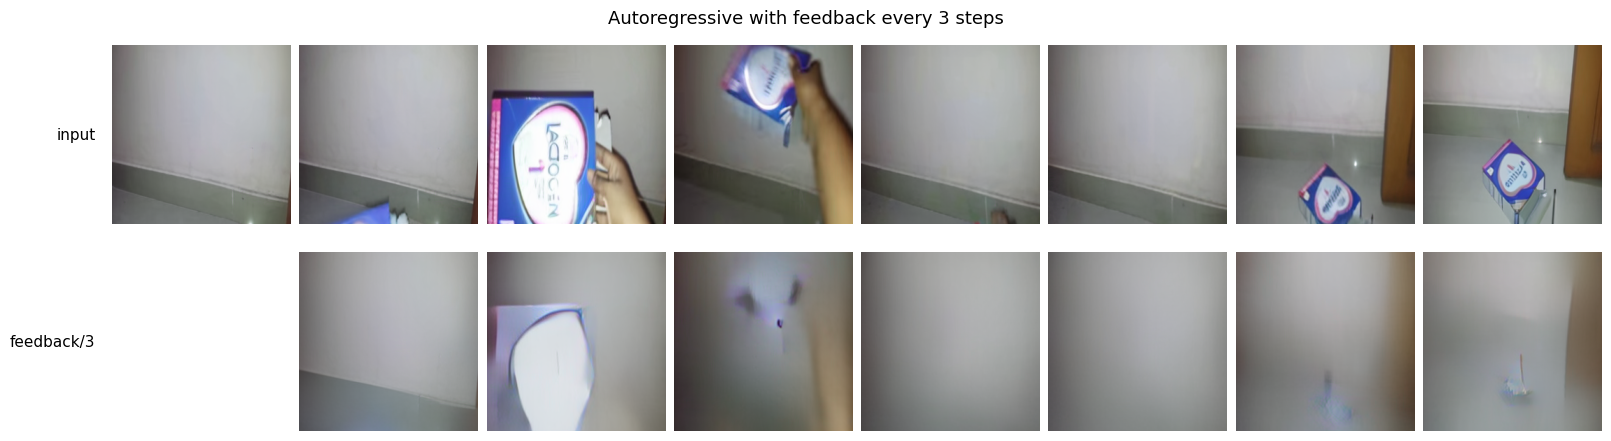

In [9]:
FEEDBACK_PERIOD = 3  # re-inject the ground-truth latent every 3 steps

with torch.no_grad():
    res_fb = model.autoregressive(X, feedback_period=FEEDBACK_PERIOD)

gt   = decode(res_fb["x"][idx])
pred = decode(res_fb["s_gen"][idx])

plot_rows(
    rows=[list(gt), [None] + list(pred)],
    row_titles=["input", f"feedback/{FEEDBACK_PERIOD}"],
    ncols=T,
    figtitle=f"Autoregressive with feedback every {FEEDBACK_PERIOD} steps",
)

## Task 3 - Autoregressive Transfer on 3D object primitive-transformation dataset

As in the paper, we evaluate transfer on our created 3D object primitive-transformation dataset: the source sequence provides
the latent transition structure, and the target sequence provides the object content.
Here we show the autoregressive transfer setting, where the transferred sequence rolls
forward from the target's first frame without teacher-forced target feedback. On Omni-Primitive-Transforms,
this transfer behavior is especially clear and performs well.

In [10]:
omni_dataset = MultiActionOmniDataset(
    img_dir=OMNI_IMG_DIR,
    transform=transform,
    seq_len=SEQ_LEN,
    rotation_actions=np.array([20]),
    plane_rotation_actions=np.array([0]),
    scale_actions=np.array([1]),
    translation_x_actions=np.array([0]),
    translation_y_actions=np.array([0]),
    initial_rotation_range=np.array([0]),
    initial_plane_rotation_range=np.array([0]),
    initial_scale_range=np.array([1]),
    initial_translation_x_range=np.array([0]),
    initial_translation_y_range=np.array([0]),
)
omni_loader = DataLoader(omni_dataset, batch_size=8, shuffle=False, num_workers=4)
omni_batch = next(iter(omni_loader))

In [11]:
with torch.no_grad():
    X_transfer = omni_batch["image_seq"].to(device)                 # -> [B, T, C, H, W]

    B_transfer, T_transfer, _, _, _ = X_transfer.size()
    X_transfer = vae.quant_conv(vae.encoder(X_transfer.flatten(0, 1)))
    X_transfer = vae.quantize.f_to_idxBl_or_fhat(
        X_transfer, to_fhat=True, v_patch_nums=vae.quantize.v_patch_nums,
    )
    X_transfer = X_transfer[-1]                                       # largest scale
    X_transfer = rearrange(
        X_transfer, "(b t) c h w -> b t c h w", b=B_transfer, t=T_transfer,
    )

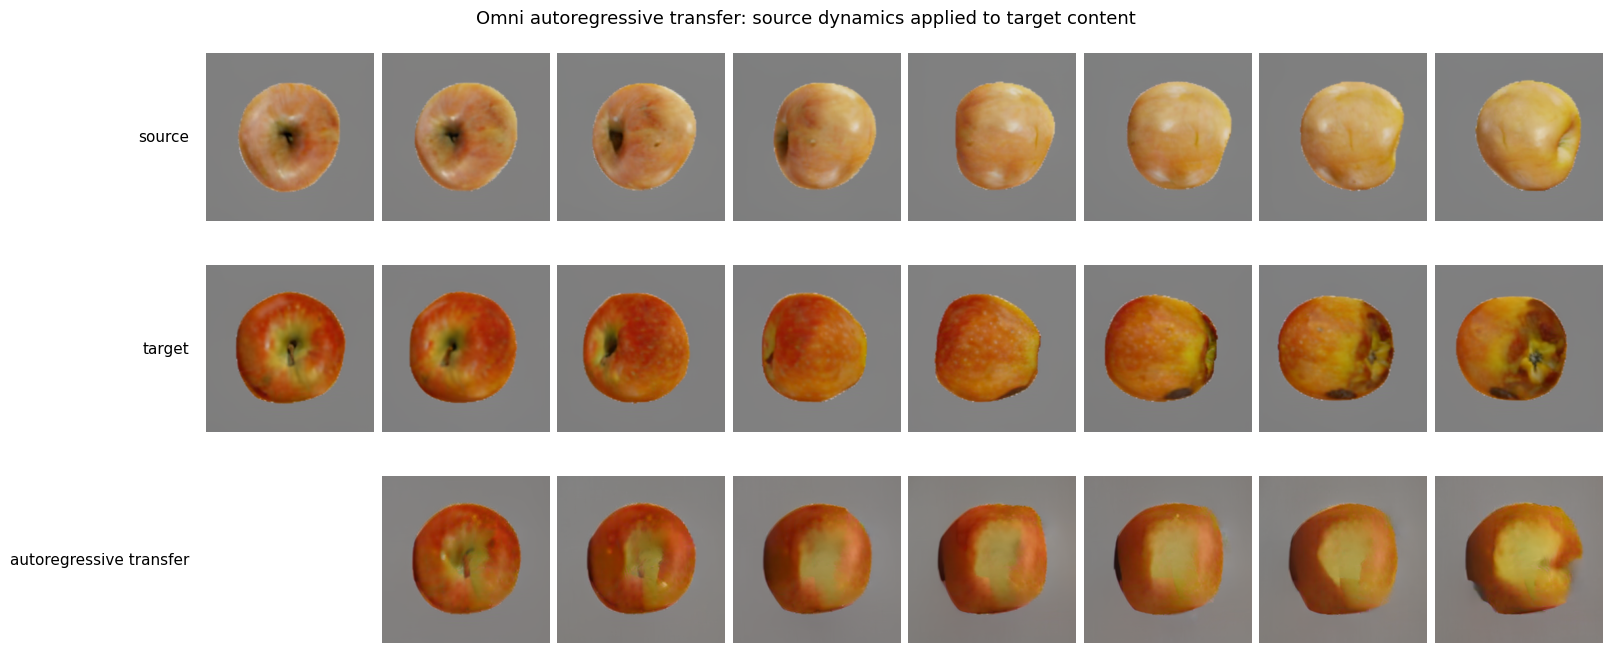

In [12]:
src_idx, tgt_idx = 3, 4  # source provides dynamics; target provides content
TRANSFER_FEEDBACK_PERIOD = None  # None = fully autoregressive; 1 = teacher-forced; N = feedback every N steps

x_src = X_transfer[src_idx:src_idx + 1]
x_tgt = X_transfer[tgt_idx:tgt_idx + 1]

with torch.no_grad():
    td = model.transfer(x_src, x_tgt, period=TRANSFER_FEEDBACK_PERIOD)

src_imgs = decode(x_src[0])            # source dynamics donor
tgt_imgs = decode(td["x"][0])          # target content
out_imgs = decode(td["s_gen"][0])      # transferred result (frames 1..T-1)

plot_rows(
    rows=[list(src_imgs), list(tgt_imgs), [None] + list(out_imgs)],
    row_titles=["source", "target", "autoregressive transfer"],
    ncols=T_transfer,
    figtitle="Omni autoregressive transfer: source dynamics applied to target content",
)